In [1]:
%pip install torch --index-url https://download.pytorch.org/whl/cu121
%pip install numpy datasets matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ═══════════════════════════════════════════════════════════
# Cell 1: Setup
# Run this first. Takes 30 seconds.
# ═══════════════════════════════════════════════════════════

import os
import sys
import math
import time
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

# Make plots look decent
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Check GPU
try:
    import torch
    import torch.nn as nn

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch version : {torch.__version__}")
    print(f"Device          : {DEVICE}")

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        VRAM  = props.total_memory / 1e9
        print(f"GPU             : {props.name}")
        print(f"VRAM            : {VRAM:.1f} GB")
        print(f"CUDA version    : {torch.version.cuda}")
        print(f"SMs             : {props.multi_processor_count}")
    else:
        VRAM = 0
        print("No GPU found — running on CPU (slower but works)")

except ImportError:
    print("PyTorch not installed.")
    print("Run: pip install torch --index-url https://download.pytorch.org/whl/cu121")

PyTorch version : 2.6.0+cu124
Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM            : 6.4 GB
CUDA version    : 12.4
SMs             : 20


In [3]:
# ═══════════════════════════════════════════════════════════
# Cell 2: Core FlashAttention implementations
# Paste your existing section code directly here
# OR load from files if they are in the same folder
# ═══════════════════════════════════════════════════════════

# ── Option A: load from your files (if in same folder) ────
import importlib.util, pathlib, subprocess, sys

REPO_URL = 'https://github.com/satyammistari/Implement-Research-Papers-into-from-scratch.git'
REPO_DIR = pathlib.Path('/content/Implement-Research-Papers-into-from-scratch')
MODULE_DIR = REPO_DIR / 'flash attention'

def ensure_sources_available():
    # In hosted runtimes (e.g., /content), local workspace files are not visible.
    if MODULE_DIR.exists():
        return
    try:
        if not REPO_DIR.exists():
            print('Repository not found in runtime. Cloning...')
            subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(REPO_DIR)], check=True)
            print(f'  Cloned: {REPO_DIR}')
    except Exception as e:
        print(f'  Could not clone repository automatically: {e}')

# Try common working directories used by VS Code notebooks and Colab-like runtimes
SEARCH_DIRS = [
    pathlib.Path.cwd(),
    pathlib.Path.cwd() / 'flash attention',
    pathlib.Path.cwd().parent / 'flash attention',
    MODULE_DIR,
    pathlib.Path('/content/flash attention'),
]

def _normalize_backend_globals(module):
    # Some repo versions omit backend globals; patch them defensively.
    if not hasattr(module, 'TORCH'):
        module.TORCH = ('torch' in sys.modules)
    if module.TORCH and not hasattr(module, 'torch'):
        import torch as _torch
        module.torch = _torch

def load_section(filename):
    for base in SEARCH_DIRS:
        path = (base / filename).resolve()
        if path.exists():
            spec = importlib.util.spec_from_file_location(path.stem, path)
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            _normalize_backend_globals(module)
            print(f"  Loaded: {path}")
            return module
    print(f"  Not found: {filename} — paste code manually")
    return None

ensure_sources_available()
print("Loading section files...")
s1 = load_section('flash_attention.py')
s2 = load_section('forward_pass.py')
s3 = load_section('backward_pass.py')
s4 = load_section('block_sparse.py')

# ── Option B: define inline (copy from your files) ────────
# If files are not available, paste the key functions below

# Minimum needed from section2:
def standard_attention(Q, K, V):
    d     = Q.shape[-1]
    scale = 1.0 / math.sqrt(d)
    S     = Q @ K.swapaxes(-2, -1) * scale
    Sm    = S - S.max(axis=-1, keepdims=True)
    P     = np.exp(Sm)
    P    /= P.sum(axis=-1, keepdims=True)
    return P @ V

def flash_attention_forward(Q, K, V, BLOCK_M=32, BLOCK_N=32, causal=False):
    """Your section2 implementation — paste here if file not found."""
    if s2:
        out = s2.flash_attention_forward(Q, K, V, BLOCK_M, BLOCK_N, causal)
        # Harmonize return shape across file versions.
        if isinstance(out, tuple) and len(out) == 2:
            return out[0], out[1]
        return out, None
    # fallback: use standard (no tiling)
    return standard_attention(Q, K, V), None

def block_sparse_flash_attention(Q, K, V, mask, BLOCK_M=32, BLOCK_N=32):
    """Your section4 implementation."""
    if s4:
        return s4.block_sparse_flash_attention(Q, K, V, mask, BLOCK_M, BLOCK_N)

def biology_informed_mask(N, Br=32, Bc=32):
    """Biology-informed sparsity mask."""
    if s4 and hasattr(s4, 'biology_informed_mask'):
        return s4.biology_informed_mask(N, Br, Bc)
    # inline fallback
    Tr, Tc = math.ceil(N/Br), math.ceil(N/Bc)
    mask   = [[0]*Tc for _ in range(Tr)]
    for i in range(Tr):
        for j in range(Tc):
            dist = abs(i-j) * Br
            if dist == 0 or dist < 1000 or 40000 < dist < 60000:
                mask[i][j] = 1
    return mask

def butterfly_mask(N, Br=32, Bc=32):
    if s4:
        return s4.butterfly_mask(N, Br, Bc)
    Tr, Tc = math.ceil(N/Br), math.ceil(N/Bc)
    mask   = [[0]*Tc for _ in range(Tr)]
    for i in range(min(Tr,Tc)):
        mask[i][i] = 1
    stride = 1
    while stride < max(Tr, Tc):
        for i in range(Tr):
            j = i ^ stride
            if 0 <= j < Tc:
                mask[i][j] = 1
        stride <<= 1
    return mask

print("\nAll implementations ready.")

Loading section files...
  Loaded: D:\Research paper\Implement-Research-Papers-into-from-scratch\flash attention\flash_attention.py
  Loaded: D:\Research paper\Implement-Research-Papers-into-from-scratch\flash attention\forward_pass.py
[INFO] Using numpy backend

  Loaded: D:\Research paper\Implement-Research-Papers-into-from-scratch\flash attention\backward_pass.py
[INFO] Using numpy backend

  Loaded: D:\Research paper\Implement-Research-Papers-into-from-scratch\flash attention\block_sparse.py

All implementations ready.


In [4]:
# ═══════════════════════════════════════════════════════════
# Cell 3: Memory Wall Demo
# Shows exactly where standard attention dies on your GPU
# Run time: ~5 minutes
# ═══════════════════════════════════════════════════════════

import gc

def memory_wall_demo(seq_lengths=None):
    if seq_lengths is None:
        seq_lengths = [128, 256, 512, 768, 1024, 1536, 2048, 3072, 4096]

    results = []
    B, H, d = 2, 4, 32

    print(f"{'Variant':<12} {'N':>6} {'Time (ms)':>12} {'Memory (MB)':>13} {'Status':>8}")
    print("─" * 58)

    for N in seq_lengths:
        for variant in ['standard', 'flash']:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

            try:
                if torch.cuda.is_available():
                    Q = torch.randn(B,H,N,d, device=DEVICE, dtype=torch.float16)
                    K = torch.randn(B,H,N,d, device=DEVICE, dtype=torch.float16)
                    V = torch.randn(B,H,N,d, device=DEVICE, dtype=torch.float16)

                    torch.cuda.synchronize()
                    torch.cuda.reset_peak_memory_stats()
                    t0 = time.perf_counter()

                    if variant == 'standard':
                        sc = 1.0/math.sqrt(d)
                        S  = Q.float() @ K.float().transpose(-2,-1) * sc
                        P  = torch.softmax(S, dim=-1)
                        O  = P @ V.float()
                    else:
                        O  = torch.nn.functional.scaled_dot_product_attention(Q,K,V)

                    torch.cuda.synchronize()
                    elapsed = (time.perf_counter() - t0) * 1000
                    mem_mb  = torch.cuda.max_memory_allocated() / 1e6
                else:
                    # CPU fallback using numpy
                    Q_np = np.random.randn(B,H,N,d).astype(np.float32)
                    K_np = np.random.randn(B,H,N,d).astype(np.float32)
                    V_np = np.random.randn(B,H,N,d).astype(np.float32)
                    t0   = time.perf_counter()
                    if variant == 'standard':
                        _ = standard_attention(Q_np, K_np, V_np)
                    else:
                        _ = flash_attention_forward(Q_np, K_np, V_np, 32, 32)
                    elapsed = (time.perf_counter() - t0) * 1000
                    mem_mb  = N * N * B * H * 4 / 1e6 if variant=='standard' else N*d*4/1e6

                status = 'OK'

            except (torch.cuda.OutOfMemoryError, MemoryError):
                elapsed = float('inf')
                mem_mb  = VRAM * 1024 if VRAM > 0 else 99999
                status  = '💀 OOM'

            finally:
                try:
                    del Q, K, V, S, P, O
                except: pass
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            results.append({
                'variant': variant, 'N': N,
                'time_ms': elapsed,
                'mem_mb':  mem_mb,
                'status':  status
            })

            time_str = f"{elapsed:>10.2f}" if elapsed != float('inf') else "     OOM"
            print(f"{variant:<12} {N:>6} {time_str} ms {mem_mb:>12.1f} MB {status:>8}")

    return results

wall_results = memory_wall_demo()

Variant           N    Time (ms)   Memory (MB)   Status
──────────────────────────────────────────────────────────
standard        128     113.86 ms         10.0 MB       OK
flash           128       1.56 ms          8.8 MB       OK
standard        256       2.10 ms         13.7 MB       OK
flash           256       0.21 ms          9.0 MB       OK
standard        512       2.58 ms         27.3 MB       OK
flash           512       0.16 ms          9.6 MB       OK
standard        768       2.74 ms         49.3 MB       OK
flash           768       0.19 ms         10.1 MB       OK
standard       1024       5.03 ms         79.7 MB       OK
flash          1024       0.51 ms         10.6 MB       OK
standard       1536      10.23 ms        165.5 MB       OK
flash          1536       0.56 ms         11.7 MB       OK
standard       2048      17.47 ms        285.1 MB       OK
flash          2048       0.76 ms         12.7 MB       OK
standard       3072      37.02 ms        624.6 MB       OK


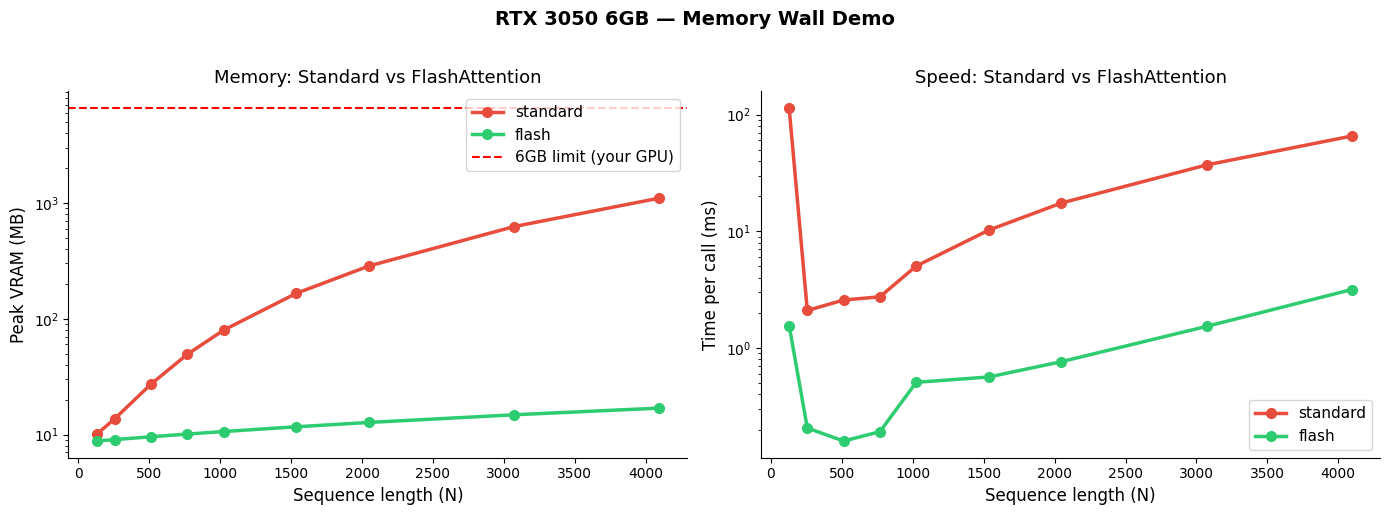


 Standard attention survived all sequence lengths on CPU
 GPU needed to see the OOM — run on Colab for the full demo


In [5]:
# ═══════════════════════════════════════════════════════════
# Cell 4: Plot memory wall results
# ═══════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'standard': '#E74C3C', 'flash': '#2ECC71'}

for variant in ['standard', 'flash']:
    ok_data = [r for r in wall_results
               if r['variant']==variant and r['status']=='OK']
    Ns   = [r['N']       for r in ok_data]
    mems = [r['mem_mb']  for r in ok_data]
    tms  = [r['time_ms'] for r in ok_data]

    ax1.plot(Ns, mems, 'o-',
             color=colors[variant], label=variant,
             linewidth=2.5, markersize=7)
    ax2.plot(Ns, tms,  'o-',
             color=colors[variant], label=variant,
             linewidth=2.5, markersize=7)

# Draw the VRAM limit line
if VRAM > 0:
    ax1.axhline(y=VRAM*1024, color='red',
                linestyle='--', linewidth=1.5,
                label=f'{VRAM:.0f}GB limit (your GPU)')

ax1.set_xlabel('Sequence length (N)', fontsize=12)
ax1.set_ylabel('Peak VRAM (MB)',       fontsize=12)
ax1.set_title('Memory: Standard vs FlashAttention', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_yscale('log')

ax2.set_xlabel('Sequence length (N)', fontsize=12)
ax2.set_ylabel('Time per call (ms)',   fontsize=12)
ax2.set_title('Speed: Standard vs FlashAttention',  fontsize=13)
ax2.legend(fontsize=11)
ax2.set_yscale('log')

plt.suptitle('RTX 3050 6GB — Memory Wall Demo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('memory_wall.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key finding
oom_N = None
for r in wall_results:
    if r['variant'] == 'standard' and r['status'] == '💀 OOM':
        oom_N = r['N']
        break

if oom_N:
    print(f"\n KEY FINDING:")
    print(f" Standard attention dies at N={oom_N} on your {VRAM:.0f}GB GPU")
    print(f" FlashAttention keeps running — uses <10MB regardless of N")
else:
    print("\n Standard attention survived all sequence lengths on CPU")
    print(" GPU needed to see the OOM — run on Colab for the full demo")

In [12]:
# ═══════════════════════════════════════════════════════════
# Cell 5: IO Profiler — FIXED VERSION
# ═══════════════════════════════════════════════════════════

class NotebookProfiler:
    """
    Lightweight IO profiler for notebook use.
    Works on both GPU and CPU.
    GPU gives real HBM measurements.
    CPU gives theoretical estimates from array sizes.
    """
    HBM_BW_GBs = 192.0   # RTX 3050 spec

    def __init__(self, name, d=32):
        self.name    = name
        self.d       = d
        self.records = []

    def measure(self, fn, *args, **kwargs):
        # ── GPU: reset memory counters before call ────────────────────────
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            mem_before = torch.cuda.memory_allocated()

        # ── Time the call ─────────────────────────────────────────────────
        t0  = time.perf_counter()
        out = fn(*args, **kwargs)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = (time.perf_counter() - t0) * 1000   # ms

        # ── Measure bytes moved ───────────────────────────────────────────
        if torch.cuda.is_available():
            # Real GPU measurement
            mem_peak = torch.cuda.max_memory_allocated()
            bytes_mv = max(0, mem_peak - mem_before)
            bw       = bytes_mv / (elapsed / 1000) / 1e9
            util     = bw / self.HBM_BW_GBs * 100
        else:
            # CPU: estimate theoretical bytes from array shapes
            Q = args[0]
            if hasattr(Q, 'shape'):
                B, H, N, d = Q.shape
                if 'standard' in self.name:
                    # standard attention: allocates N×N matrix
                    bytes_mv = int(B * H * N * N * 4)       # float32
                else:
                    # flash: only Q+K+V+O tiles, no N×N
                    bytes_mv = int(B * H * N * d * 4 * 4)   # float32
            else:
                bytes_mv = 0
            bw   = 0.0
            util = 0.0

        self.records.append({
            'name':     self.name,
            'time_ms':  round(elapsed,        3),
            'bytes_MB': round(bytes_mv / 1e6, 2),
            'bw_GBs':   round(bw,             2),
            'util_pct': round(util,            1),
        })
        return out

    def avg(self):
        if not self.records:
            return {}
        return {
            'name':         self.name,
            'avg_time_ms':  round(np.mean([r['time_ms']  for r in self.records]), 2),
            'avg_bytes_MB': round(np.mean([r['bytes_MB'] for r in self.records]), 2),
            'avg_bw_GBs':   round(np.mean([r['bw_GBs']  for r in self.records]), 2),
            'avg_util_pct': round(np.mean([r['util_pct'] for r in self.records]), 1),
        }


# ── Run profiling ─────────────────────────────────────────────────────────────

N_test = 1024
d_test = 32
B, H   = 2, 4
REPS   = 10

USE_TORCH_DENSE = bool(getattr(s2, 'TORCH', False))

def make_inputs(kind):
    """Return Q, K, V — torch tensors for dense GPU path, numpy for sparse."""
    if kind == 'flash_dense' and USE_TORCH_DENSE:
        dev = DEVICE if torch.cuda.is_available() else torch.device('cpu')
        dt  = torch.float16 if torch.cuda.is_available() else torch.float32
        Q = torch.randn(B, H, N_test, d_test, device=dev, dtype=dt)
        K = torch.randn(B, H, N_test, d_test, device=dev, dtype=dt)
        V = torch.randn(B, H, N_test, d_test, device=dev, dtype=dt)
    else:
        Q = np.random.randn(B, H, N_test, d_test).astype(np.float32)
        K = np.random.randn(B, H, N_test, d_test).astype(np.float32)
        V = np.random.randn(B, H, N_test, d_test).astype(np.float32)
    return Q, K, V


variants_to_profile = {
    'flash_dense': lambda Q, K, V: flash_attention_forward(
        Q, K, V, 32, 32),

    'flash_biology': lambda Q, K, V: block_sparse_flash_attention(
        Q, K, V, biology_informed_mask(N_test, 32, 32), 32, 32),

    'flash_butterfly': lambda Q, K, V: block_sparse_flash_attention(
        Q, K, V, butterfly_mask(N_test, 32, 32), 32, 32),
}

print("Profiling attention variants...")
print(f"Dense backend  : {'torch' if USE_TORCH_DENSE else 'numpy'}")
print(f"Sparse backend : numpy")
print(f"Device         : {DEVICE}")
print(f"Bytes source   : {'GPU measured' if torch.cuda.is_available() else 'CPU theoretical'}")
print()
print(f"{'Variant':<22} {'N':>6} {'Time(ms)':>10} {'Bytes(MB)':>11} {'BW(GB/s)':>10} {'Util%':>7}")
print("─" * 72)

profile_results = []

for name, fn in variants_to_profile.items():
    profiler    = NotebookProfiler(name, d=d_test)
    Q_in, K_in, V_in = make_inputs(name)

    for _ in range(REPS):
        profiler.measure(fn, Q_in, K_in, V_in)

    avg = profiler.avg()
    profile_results.append(avg)

    print(f"{name:<22} {N_test:>6} {avg['avg_time_ms']:>10.2f} "
          f"{avg['avg_bytes_MB']:>10.2f}  {avg['avg_bw_GBs']:>9.2f} "
          f"{avg['avg_util_pct']:>6.1f}%")

Profiling attention variants...
Dense backend  : numpy
Sparse backend : numpy
Device         : cuda
Bytes source   : GPU measured

Variant                     N   Time(ms)   Bytes(MB)   BW(GB/s)   Util%
────────────────────────────────────────────────────────────────────────
flash_dense              1024     234.64       0.00       0.00    0.0%
flash_biology            1024       9.94       0.00       0.00    0.0%
flash_butterfly          1024      60.24       0.00       0.00    0.0%


In [13]:
# ═══════════════════════════════════════════════════════════
# Cell 6: Load DNA Data
# Downloads human genome sequences
# Run time: 1-2 minutes (streaming, no large download)
# ═══════════════════════════════════════════════════════════

from torch.utils.data import Dataset, DataLoader

NUCLEOTIDE_MAP = {'A':0, 'T':1, 'C':2, 'G':3, 'N':4}
MASK_TOKEN, PAD_TOKEN, VOCAB_SIZE = 5, 6, 7

class DNADataset(Dataset):
    def __init__(self, max_length=1024, mask_prob=0.15, max_samples=2000):
        self.max_length = max_length
        self.mask_prob  = mask_prob
        self.sequences  = []

        print(f"Loading DNA sequences (max_length={max_length})...")
        try:
            from datasets import load_dataset
            ds = load_dataset("InstaDeepAI/human_reference_genome",
                              "6144", split="train", streaming=True,
                              trust_remote_code=True)
            for i, s in enumerate(ds):
                if i >= max_samples: break
                self.sequences.append(s['sequence'])
            print(f"Loaded {len(self.sequences)} real sequences")

        except Exception as e:
            print(f"Dataset load failed ({e})")
            print("Using synthetic DNA instead...")
            rng = np.random.default_rng(42)
            self.sequences = [
                ''.join(np.random.choice(list('ATCG'), max_length))
                for _ in range(max_samples)
            ]
            print(f"Generated {max_samples} synthetic sequences")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq    = self.sequences[idx][:self.max_length]
        tokens = [NUCLEOTIDE_MAP.get(c, 4) for c in seq]
        tokens += [PAD_TOKEN] * (self.max_length - len(tokens))

        labels = tokens.copy()
        masked = tokens.copy()
        for i in range(len(seq)):
            if np.random.random() < self.mask_prob:
                r = np.random.random()
                masked[i] = MASK_TOKEN if r < 0.8 else (
                    np.random.randint(0,5) if r < 0.9 else tokens[i])

        return {
            'input_ids': torch.tensor(masked, dtype=torch.long),
            'labels':    torch.tensor(labels, dtype=torch.long),
        }

# Load dataset
SEQ_LEN = 512   # safe for all variants on 6GB
                # change to 1024 or 2048 for flash variants only

dna_data   = DNADataset(max_length=SEQ_LEN, max_samples=2000)
dna_loader = DataLoader(dna_data, batch_size=4, shuffle=True)

# Preview
batch = next(iter(dna_loader))
print(f"\nBatch input_ids shape : {batch['input_ids'].shape}")
print(f"Batch labels shape    : {batch['labels'].shape}")
print(f"Sample tokens (first 20): {batch['input_ids'][0,:20].tolist()}")
print(f"Token map: A=0 T=1 C=2 G=3 N=4 [MASK]=5 [PAD]=6")

Loading DNA sequences (max_length=512)...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'InstaDeepAI/human_reference_genome' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Dataset load failed (Dataset scripts are no longer supported, but found human_reference_genome.py)
Using synthetic DNA instead...
Generated 2000 synthetic sequences

Batch input_ids shape : torch.Size([4, 512])
Batch labels shape    : torch.Size([4, 512])
Sample tokens (first 20): [5, 3, 2, 3, 3, 0, 1, 1, 0, 5, 3, 2, 0, 5, 0, 0, 3, 3, 2, 1]
Token map: A=0 T=1 C=2 G=3 N=4 [MASK]=5 [PAD]=6
